In [4]:
!rm -rf mnist-cnn-foss
!unzip -q mnist-cnn-foss-submission.zip
!ls mnist-cnn-foss

LICENSE  models  README.md  requirements.txt  results  src  SUBMISSION.md


In [5]:
!pip install -q -r mnist-cnn-foss/requirements.txt

In [6]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


In [7]:
!cd mnist-cnn-foss && python src/train.py

MNIST CNN - Training
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28, 1)
Test images:     (10000, 28, 28, 1)
2026-10-04 10:43:45.456076: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)

Model architecture:
Model: "mnist_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├────────────────

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [8]:
!find mnist-cnn-foss/results -maxdepth 1 -type f -print

mnist-cnn-foss/results/loss.png
mnist-cnn-foss/results/.gitkeep
mnist-cnn-foss/results/predictions.png
mnist-cnn-foss/results/metrics.txt
mnist-cnn-foss/results/accuracy.png


In [9]:
!cat mnist-cnn-foss/results/metrics.txt

Test Accuracy: 0.9925 (99.25%)
Test Loss: 0.0255
Epochs: 10
Batch Size: 128
Optimizer: Adam
Loss Function: Sparse Categorical Crossentropy


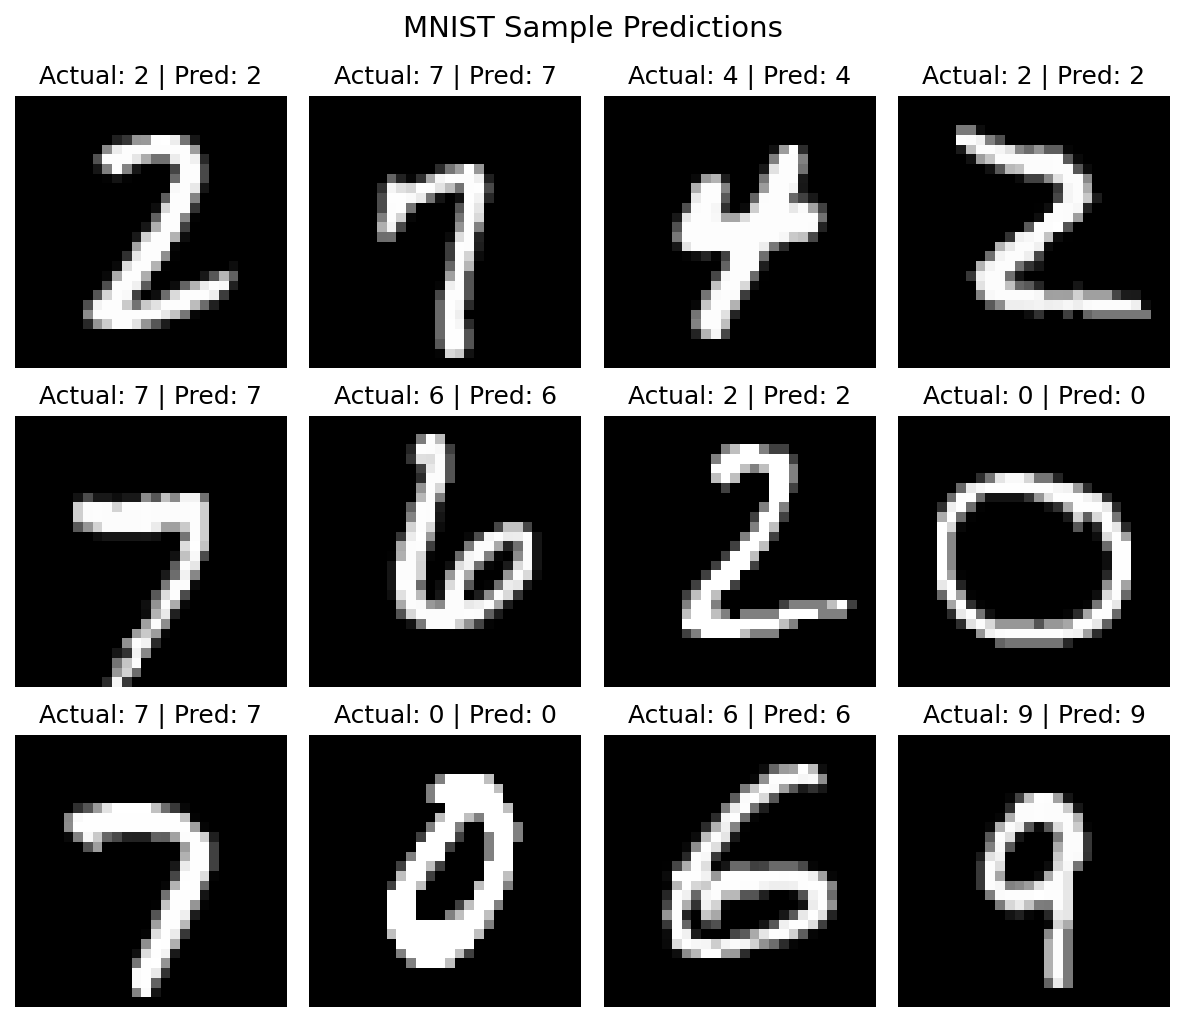

In [10]:
from IPython.display import Image, display

display(Image("mnist-cnn-foss/results/predictions.png"))

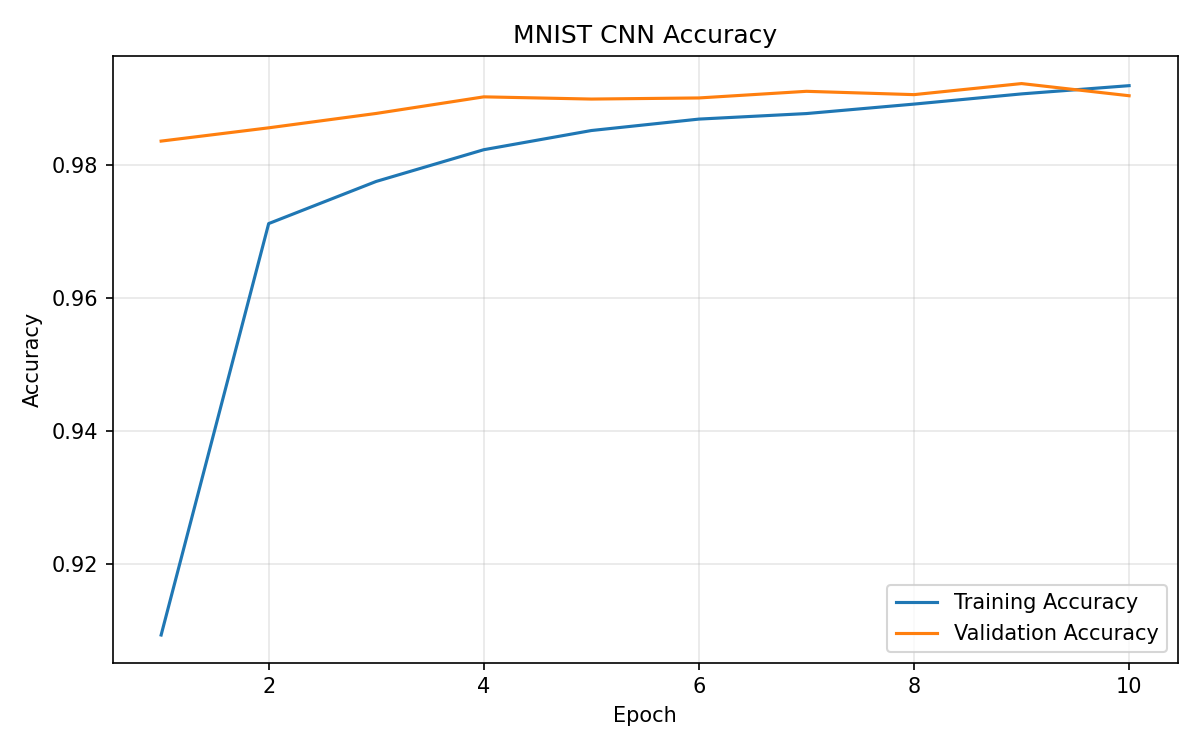

In [11]:
display(Image("mnist-cnn-foss/results/accuracy.png"))

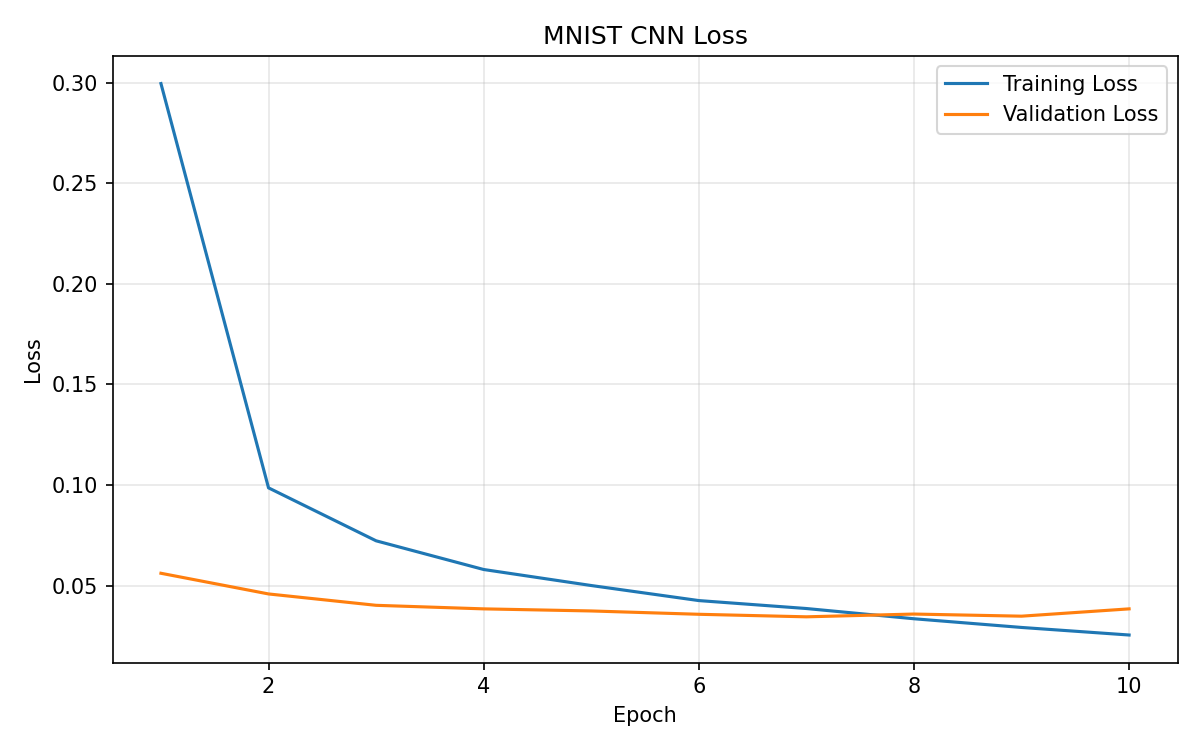

In [12]:
display(Image("mnist-cnn-foss/results/loss.png"))

In [13]:
!cd mnist-cnn-foss && python src/predict.py

2026-10-04 10:56:33.418358: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Predictions saved to: /content/mnist-cnn-foss/results/predictions.png


In [14]:
from tensorflow import keras

model = keras.models.load_model(
    "mnist-cnn-foss/models/mnist_cnn.keras"
)

model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [15]:
!find mnist-cnn-foss -maxdepth 2 -type f | sort

mnist-cnn-foss/.gitignore
mnist-cnn-foss/LICENSE
mnist-cnn-foss/models/.gitkeep
mnist-cnn-foss/models/mnist_cnn.keras
mnist-cnn-foss/README.md
mnist-cnn-foss/requirements.txt
mnist-cnn-foss/results/accuracy.png
mnist-cnn-foss/results/.gitkeep
mnist-cnn-foss/results/loss.png
mnist-cnn-foss/results/metrics.txt
mnist-cnn-foss/results/predictions.png
mnist-cnn-foss/src/predict.py
mnist-cnn-foss/src/train.py
mnist-cnn-foss/SUBMISSION.md


In [16]:
from google.colab import files

files.download('mnist-cnn-foss/results/accuracy.png')
files.download('mnist-cnn-foss/results/loss.png')
files.download('mnist-cnn-foss/results/predictions.png')
files.download('mnist-cnn-foss/results/metrics.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>